## Lista de Exercícios 17/04/2026

In [7]:
import gurobipy as gp

#### Ex3:
- dimensão das chapas: 1,40 x 0,50 metros
- diametro corte medio: 0.25 metros
- diametro corte grande: 0.40 metros
- demanda mínima de corte médio: 500
- demanda mínima de corte grande: 350

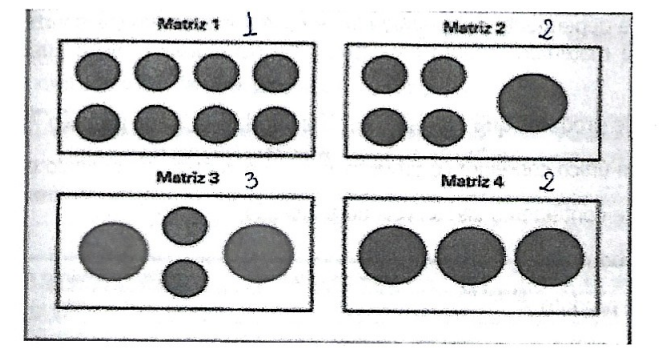

In [32]:
m = gp.Model("ex3-CorteDeChapasMetalicas")
x = m.addVars([1, 2, 3, 4], lb=0, vtype=gp.GRB.INTEGER, name="matriz")

obj = 1*x[1] + 2*x[2] + 3*x[3] + 2*x[4]
m.setObjective(obj, gp.GRB.MINIMIZE)

In [33]:
m.addConstr(8*x[1] + 4*x[2] + 2*x[3] >= 500, name="corte_medio")
m.addConstr(1*x[2] + 2*x[3] + 3*x[4] >= 350, name="corte_grande")

<gurobi.Constr *Awaiting Model Update*>

In [34]:
m.write("model3.lp")

In [35]:
m.optimize()

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2 rows, 4 columns and 6 nonzeros
Model fingerprint: 0xe67e1b6b
Variable types: 0 continuous, 4 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+00]
  Objective range  [1e+00, 3e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+02, 5e+02]
Found heuristic solution: objective 750.0000000
Presolve time: 0.00s
Presolved: 2 rows, 4 columns, 6 nonzeros
Variable types: 0 continuous, 4 integer (0 binary)

Root relaxation: objective 2.958333e+02, 2 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0  295.83333    0    2  750.00000  

In [36]:
if m.status == gp.GRB.OPTIMAL:
    print(f"\nCusto Total Mínimo: {m.objVal}")
    print("-" * 30)
    for i in range(1, 5):
        if x[i].X > 0:
            print(f"Matriz {i}: {int(x[i].X)} chapas")
    
    tot_media = 8*x[1].X + 4*x[2].X + 2*x[3].X
    tot_grande = 1*x[2].X + 2*x[3].X + 3*x[4].X
    print(f"Total produzido: {int(tot_media)} médias e {int(tot_grande)} grandes")
else:
    print("Solução ótima não encontrada.")


Custo Total Mínimo: 297.0
------------------------------
Matriz 1: 63 chapas
Matriz 4: 117 chapas
Total produzido: 504 médias e 351 grandes


#### Ex4:
        P1 ==> Node 1

        P2 ==> Node 2

        T1 ==> Node 3

        T2 ==> Node 4

        D1 ==> Node 5

        D2 ==> Node 6

        D3 ==> Node 7

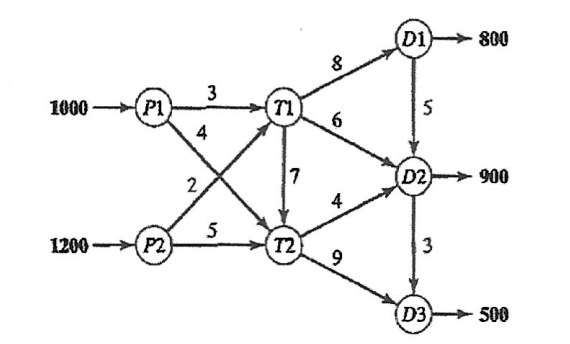

In [13]:
m = gp.Model("ex4-FabricaAutomovel")
x = m.addVars([1, 2, 3, 4, 5, 6], [3, 4, 5, 6, 7], lb=0, vtype=gp.GRB.INTEGER, name="qtd carros enviados")

obj = 3*x[1,3] + 4*x[1,4] + 2*x[2,3] + 5*x[2,4] + 7*x[3,4] + 8*x[3,5] + 6*x[3,6] + 4*x[4,6] + 9*x[4,7] + 5*x[5,6] + 3*x[6,7]
m.setObjective(obj, gp.GRB.MINIMIZE)

Set parameter Username
Set parameter LicenseID to value 2810550
Academic license - for non-commercial use only - expires 2027-04-20


In [14]:
m.addConstr(x[1,3] + x[1,4] == 1000, name="rest_no1")
m.addConstr(x[2,3] + x[2,4] == 1200, name="rest_no2")
m.addConstr(x[3,4] + x[3,5] + x[3,6] == x[1,3] + x[2,3], name="rest_no3")
m.addConstr(x[4,6] + x[4,7] == x[1,4] + x[2,4] + x[3,4], name="rest_no4")
m.addConstr(x[5,6] + 800 == x[3,5], name="rest_no5")
m.addConstr(900 + x[6,7] == x[3,6] + x[4,6] + x[5,6], name="rest_no6")
m.addConstr(x[4,7] + x[6,7] == 500, name="rest_no7")


<gurobi.Constr *Awaiting Model Update*>

In [15]:
m.write("model4.lp")

In [16]:
m.optimize()

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 7 rows, 30 columns and 22 nonzeros
Model fingerprint: 0x42a97417
Variable types: 0 continuous, 30 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+00, 9e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+02, 1e+03]
Found heuristic solution: objective 31500.000000
Presolve removed 7 rows and 30 columns
Presolve time: 0.01s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.03 seconds (0.00 work units)
Thread count was 1 (of 8 available processors)

Solution count 2: 20700 31500 

Optimal solution found (tolerance 1.00e-04)
Best objective 2.070000000000e+04, best bound 2.070000000000e+04, gap 0.0000%


In [17]:
if m.status == gp.GRB.OPTIMAL:
    print(f"\nCusto Total Mínimo: {m.objVal}")
    print("-" * 30)
    for chave, var in x.items():
        if var.X > 0:
            print(f"Trajeto {chave} (Origem {chave[0]} -> Destino {chave[1]}): {var.X}")
else:
    print("O modelo não encontrou uma solução ótima.")


Custo Total Mínimo: 20700.0
------------------------------
Trajeto (1, 4) (Origem 1 -> Destino 4): 1000.0
Trajeto (2, 3) (Origem 2 -> Destino 3): 1200.0
Trajeto (3, 5) (Origem 3 -> Destino 5): 800.0
Trajeto (3, 6) (Origem 3 -> Destino 6): 400.0
Trajeto (4, 6) (Origem 4 -> Destino 6): 1000.0
Trajeto (6, 7) (Origem 6 -> Destino 7): 500.0


#### Ex6:

1. Índices
- $I = \{1, 2, \dots, i\}$: Conjunto de **Produtos**.
- $J = \{1, 2, \dots, j\}$: Conjunto de **Contêineres**.

2. Variáveis de Decisão Binárias
- $x_{ij} \in \{0, 1\}$: Assume **1** se o produto $i$ for alocado no contêiner $j$; **0** caso contrário.
- $y_j \in \{0, 1\}$: Assume **1** se o contêiner $j$ for efetivamente alugado; **0** caso contrário.

3. Inputs
- $w_i$: Peso do produto $i$.
- $v_i$: Volume do produto $i$.
- $CapP_j$: Capacidade de peso do contêiner $j$.
- $CapV_j$: Capacidade de volume do contêiner $j$.
- $A_j$: Custo de aluguel do contêiner $j$.

4. **Função Objetivo**: 
Minimizar o custo total de locação
$$\text{Min } Z = \sum_{j \in J} A_j \cdot y_j$$

5. **Restrições**

- Cada produto deve estar em exatamente um contêiner (não pode ser dividido).
$$\sum_{j \in J} x_{ij} = 1, \quad \forall i \in I$$

- O peso total dos produtos não pode exceder o limite de peso do conteiner. Além disso, se houver produtos ($x_{ij}=1$), o contêiner deve ser pago ($y_j=1$).
$$\sum_{i \in I} w_i \cdot x_{ij} \le CapP_j \cdot y_j, \quad \forall j \in J$$

- O volume total dos produtos não pode exceder o limite de volume do conteiner. Além disso, se houver produtos ($x_{ij}=1$), o contêiner deve ser pago ($y_j=1$).
$$\sum_{i \in I} v_i \cdot x_{ij} \le CapV_j \cdot y_j, \quad \forall j \in J$$

- Domínio das Variáveis:
$$x_{ij}, y_j \in \{0, 1\}$$